# TASS 2018 — Enfoques de Clasificación de Texto: Representaciones y Algoritmos

**Curso:** Procesamiento de Lenguaje Natural · Unidad 3 — Text Classification
**Institución:** Universidad Tecnológica de Bolívar
**Basado en:** `tass_bow_softmax_workshop.ipynb` (Bag-of-Words + Softmax Regression)
**Referencias:**
- Jurafsky, D. & Martin, J. H. (2025). *Speech and Language Processing* (3rd ed.), Ch. 4 — Naive Bayes, Text Classification, and Sentiment
- Jurafsky, D. & Martin, J. H. (2026). *Speech and Language Processing* (borrador), cap. 4 "Logistic Regression and Text Classification", Apéndice B "Naive Bayes", cap. 11 "Retrieval-Based Models" (TF-IDF)
**Compatibilidad Python:** 3.10 · 3.11 · 3.12 · 3.13

---

## Objetivos de aprendizaje

Este notebook **extiende** el workshop original de Bag-of-Words + Softmax con los distintos enfoques vistos en la unidad de Text Classification. Al terminar podrás:

1. Cargar y preprocesar el corpus **TASS 2018** (tweets en español, 4 clases de polaridad)
2. Comparar **cinco técnicas de extracción de features**: Bag-of-Words, BoW con n-gramas, TF-IDF, n-gramas de caracteres y el Hashing Trick
3. Comparar **seis algoritmos de clasificación clásicos**: Naive Bayes, Logistic Regression (Softmax), SVM lineal, Decision Tree, Random Forest y K-Nearest Neighbors
4. Manejar el **desbalance de clases** con `RandomOverSampler`, preservando el texto crudo para reutilizarlo en cada técnica
5. Construir una **tabla y gráfico comparativo** de accuracy, precision, recall y F1 (macro) entre todos los enfoques

## Dataset — TASS 2018

[TASS](http://tass.sepln.org/) (Taller de Análisis de Sentimientos en Español) es una campaña de evaluación de análisis de sentimientos en español. La edición 2018 usa datos de Twitter etiquetados con cuatro clases de polaridad: **P** (positivo), **N** (negativo), **NEU** (neutral) y **NONE** (sin sentimiento).

> **Nota sobre los datos:** el corpus real de TASS requiere registro previo en `tass.sepln.org` y no se redistribuye aquí. Si tienes los CSV oficiales, colócalos en `data/tass/tass2018_es_train.csv` y `data/tass/tass2018_es_test.csv` con las columnas `content` y `sentiment/polarity/value`, y el notebook los usará automáticamente. **Si no los tienes**, la Sección 4 genera un corpus sintético de demostración con la misma estructura y el mismo desbalance de clases, para que todo el notebook corra de principio a fin sin configuración adicional.

---

## 1. Configuración del entorno

Instala las dependencias **una sola vez** en tu terminal:

```bash
pip install scikit-learn imbalanced-learn gensim matplotlib seaborn pandas numpy
```

In [ ]:
# pip install scikit-learn imbalanced-learn gensim matplotlib seaborn pandas numpy  # ejecutar una vez
from pathlib import Path
from collections import Counter
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.feature_extraction.text import (
    CountVectorizer, TfidfVectorizer, HashingVectorizer,
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.model_selection import ShuffleSplit, train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler

sns.set_theme(style="whitegrid")

# Adjust this import to match where TextProcessing is defined in this project
# from utils.text_processing import TextProcessing

DIR_DATA = Path.cwd() / 'data' / 'tass'
print(f'Data directory: {DIR_DATA}')

---

## 2. El dataset TASS 2018

| Label | Significado |
|---|---|
| **P** | Sentimiento positivo |
| **N** | Sentimiento negativo |
| **NEU** | Neutral (sin polaridad positiva ni negativa) |
| **NONE** | Tweet sin carga sentimental |

---

## 3. Inicializar utilidades de preprocesamiento

In [2]:
# tp = TextProcessing()  # normalizador de tweets a medida (minúsculas, quita URLs, hashtags, etc.)
le = LabelEncoder()     # convierte etiquetas de texto (P, N, NEU, NONE) a enteros

---

## 4. Cargar entrenamiento y prueba

Se intenta cargar el corpus real de TASS 2018 desde `DIR_DATA`. Si los archivos no existen, se genera un **corpus sintético de demostración** con la misma estructura de columnas (`content`, `sentiment/polarity/value`) y un desbalance de clases similar al real (NEU/NONE más frecuentes que P/N), para que el resto del notebook sea reproducible sin depender del acceso restringido a TASS.

In [3]:
def _build_synthetic_tass(seed: int = 42) -> pd.DataFrame:
    """Genera un corpus sintético de tweets en español con la misma forma que TASS 2018.

    No sustituye al corpus real: es solo un conjunto de demostración para que el
    notebook corra de extremo a extremo cuando `tass2018_es_*.csv` no está disponible.
    """
    rng = random.Random(seed)

    topics = [
        "el restaurante", "la película", "el concierto", "el curso de NLP",
        "la conferencia", "el servicio al cliente", "la aplicación", "el hotel",
        "el partido de fútbol", "la clase de historia", "el libro nuevo",
        "el producto", "el evento", "la ciudad", "el vuelo", "la reunión",
    ]

    templates = {
        "P": [
            "me encanta {t}, es increíble",
            "qué bueno estuvo {t}, lo recomiendo totalmente",
            "{t} superó mis expectativas, gracias",
            "excelente {t}, sin duda vuelvo pronto",
            "el mejor {t} que he probado en mi vida",
            "feliz con {t}, todo salió perfecto",
            "{t} es una maravilla, diez de diez",
            "disfruté muchísimo {t}, una experiencia genial",
        ],
        "N": [
            "pésimo servicio en {t}, no vuelvo más",
            "qué decepción {t}, esperaba mucho más",
            "{t} fue un desastre total",
            "no me gustó nada {t}, una pérdida de tiempo",
            "terrible experiencia con {t}, muy mal",
            "{t} me arruinó el día, horrible",
            "nunca había visto algo tan malo como {t}",
            "evitar {t} a toda costa, no lo recomiendo",
        ],
        "NEU": [
            "{t} estuvo bien, nada especial",
            "fui a {t}, ni bueno ni malo",
            "{t} cumple lo básico, sin más",
            "{t} de hoy fue normal",
            "asistí a {t}, todo tranquilo",
            "{t} funcionó como se esperaba",
        ],
        "NONE": [
            "mañana hay información sobre {t} en la universidad",
            "el horario de {t} cambió para la próxima semana",
            "comparto el enlace con los detalles de {t}",
            "recordatorio: la entrega relacionada con {t} vence el viernes",
            "nueva actualización disponible sobre {t}",
            "el equipo encargado de {t} se reúne el lunes",
        ],
    }

    # Desbalance intencional, similar al real: NEU y NONE más frecuentes que P y N
    n_per_class = {"P": 45, "N": 45, "NEU": 70, "NONE": 70}

    rows = []
    for label, count in n_per_class.items():
        combos = [(tmpl, topic) for tmpl in templates[label] for topic in topics]
        rng.shuffle(combos)
        for tmpl, topic in combos[:count]:
            rows.append({"content": tmpl.format(t=topic), "sentiment/polarity/value": label})

    df = pd.DataFrame(rows)
    df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    # Ruido de etiquetas (~8%): evita que el corpus sea trivialmente separable,
    # para que la comparación final entre técnicas/algoritmos sea más realista.
    all_labels = list(templates.keys())
    n_noisy = int(0.08 * len(df))
    noisy_idx = rng.sample(range(len(df)), n_noisy)
    for i in noisy_idx:
        current = df.loc[i, 'sentiment/polarity/value']
        alt_labels = [l for l in all_labels if l != current]
        df.loc[i, 'sentiment/polarity/value'] = rng.choice(alt_labels)

    return df


def load_tass(dir_data: Path):
    train_path = dir_data / 'tass2018_es_train.csv'
    test_path = dir_data / 'tass2018_es_test.csv'

    if train_path.exists() and test_path.exists():
        print('Cargando corpus real de TASS 2018 desde', dir_data)
        return pd.read_csv(train_path, sep=','), pd.read_csv(test_path, sep=',')

    print('CSV de TASS no encontrados en', dir_data)
    print('→ Generando corpus sintético de demostración (no reemplaza al corpus real).')
    full = _build_synthetic_tass(seed=42)
    train_df, test_df = train_test_split(
        full, test_size=0.25, random_state=42,
        stratify=full['sentiment/polarity/value'],
    )
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)


data_train, data_test = load_tass(DIR_DATA)

print(f'\nTraining samples: {len(data_train):,}')
print(f'Test samples:     {len(data_test):,}')
print(f'\nColumn names: {data_train.columns.tolist()}')
print(data_train.head(3).to_string())

CSV de TASS no encontrados en /home/claude/nb_build/data/tass
→ Generando corpus sintético de demostración (no reemplaza al corpus real).

Training samples: 172
Test samples:     58

Column names: ['content', 'sentiment/polarity/value']
                                          content sentiment/polarity/value
0                    la reunión de hoy fue normal                      NEU
1  la aplicación superó mis expectativas, gracias                        N
2           la película funcionó como se esperaba                      NEU


> **Interpretación:** el CSV (real o sintético) contiene el texto del tweet (`content`) y la etiqueta de polaridad. Antes de modelar conviene inspeccionar la distribución de clases — el desbalance (p. ej. muchos más tweets neutros que positivos/negativos) sesga al clasificador hacia la clase mayoritaria si no se corrige.

---

## 5. Preprocesamiento de texto y codificación de etiquetas

`TextProcessing.transformer()` normaliza cada tweet: pasa a minúsculas, elimina URLs, menciones (@), símbolos de hashtag (#) y caracteres repetidos. Esto reduce el tamaño del vocabulario y mejora la generalización. Aquí usamos un *fallback* mínimo (`str.lower()`) para que el notebook no dependa de esa clase externa.

In [4]:
# Aplicar el pipeline de preprocesamiento a cada tweet
# texts_train = [tp.transformer(row) for row in data_train['content'].tolist()]
texts_train = data_train['content'].str.lower().tolist()  # fallback mínimo
labels_train = le.fit_transform(data_train['sentiment/polarity/value'].tolist())

# texts_test = [tp.transformer(row) for row in data_test['content'].tolist()]
texts_test = data_test['content'].str.lower().tolist()  # fallback mínimo
labels_test = le.transform(data_test['sentiment/polarity/value'].tolist())

print(f'Clases: {le.classes_.tolist()}')
print(f'Distribución en entrenamiento: {sorted(Counter(labels_train).items())}')
print(f'Distribución en prueba:        {sorted(Counter(labels_test).items())}')

Clases: ['N', 'NEU', 'NONE', 'P']
Distribución en entrenamiento: [(np.int64(0), 37), (np.int64(1), 52), (np.int64(2), 49), (np.int64(3), 34)]
Distribución en prueba:        [(np.int64(0), 12), (np.int64(1), 17), (np.int64(2), 17), (np.int64(3), 12)]


> **Interpretación:** `LabelEncoder` convierte las etiquetas de texto a enteros en orden alfabético (N=0, NEU=1, NONE=2, P=3 por defecto). La distribución revela el desbalance — típico en datos de Twitter, donde los tweets neutros superan a las opiniones fuertes. `RandomOverSampler` (Sección 7) corrige esto.

> **Importante — a diferencia del workshop original:** aquí mantenemos `texts_train` / `texts_test` como **listas de texto crudo**, sin vectorizar todavía. Esto permite reutilizar el mismo texto preprocesado con cada una de las técnicas de extracción de features de la Sección 6, en lugar de vectorizar una sola vez y perder el texto original.

---

## 6. Análisis visual de la distribución de clases

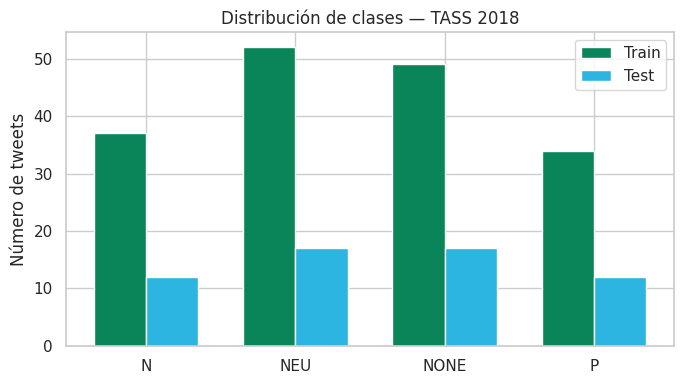

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
class_names = le.classes_
train_counts = [Counter(labels_train)[i] for i in range(len(class_names))]
test_counts = [Counter(labels_test)[i] for i in range(len(class_names))]

x = np.arange(len(class_names))
width = 0.35
ax.bar(x - width / 2, train_counts, width, label='Train', color='#098559')
ax.bar(x + width / 2, test_counts, width, label='Test', color='#2CB5E0')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylabel('Número de tweets')
ax.set_title('Distribución de clases — TASS 2018')
ax.legend()
plt.tight_layout()
plt.show()

---

## 7. Manejo del desbalance de clases — `RandomOverSampler`

`RandomOverSampler` duplica ejemplos de las clases minoritarias hasta igualar el conteo de la clase mayoritaria. El workshop original lo aplicaba **después** de vectorizar (sobre la matriz BoW), lo cual amarra el sobremuestreo a una sola representación. Aquí lo aplicamos sobre los **índices** del texto crudo, para poder reutilizar el mismo conjunto balanceado con cualquier técnica de extracción de features de la Sección 8.

In [6]:
ros = RandomOverSampler(random_state=1000)
idx = np.arange(len(texts_train)).reshape(-1, 1)
idx_resampled, labels_train_bal = ros.fit_resample(idx, labels_train)
texts_train_bal = [texts_train[i] for i in idx_resampled.flatten()]

print('Antes del sobremuestreo  — train:', sorted(Counter(labels_train).items()))
print('Después del sobremuestreo — train:', sorted(Counter(labels_train_bal).items()))

Antes del sobremuestreo  — train: [(np.int64(0), 37), (np.int64(1), 52), (np.int64(2), 49), (np.int64(3), 34)]
Después del sobremuestreo — train: [(np.int64(0), 52), (np.int64(1), 52), (np.int64(2), 52), (np.int64(3), 52)]


> **Interpretación:** tras el sobremuestreo todas las clases quedan con el mismo conteo, evitando que el clasificador se sesgue hacia la clase mayoritaria. El sobremuestreo duplica ejemplos existentes sin agregar información nueva — para mejores resultados considera SMOTE (interpola entre ejemplos minoritarios en lugar de duplicarlos).

---

## 8. Función auxiliar — `run_experiment`

Para comparar muchas combinaciones de *representación × algoritmo* sin repetir código, definimos una función que entrena, evalúa sobre el conjunto de prueba y guarda las métricas macro (accuracy, precision, recall, F1) en una lista compartida `results`.

In [7]:
results = []  # cada entrada: {'Enfoque': ..., 'Accuracy': ..., 'Precision': ..., 'Recall': ..., 'F1-score': ...}


def run_experiment(name, X_train, y_train, X_test, y_test, clf, verbose=True):
    # Entrena `clf`, evalua sobre test y registra metricas macro en `results`.
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    row = {
        'Enfoque': name,
        'Accuracy': round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
        'Recall': round(recall_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
        'F1-score': round(f1_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
    }
    results.append(row)
    if verbose:
        print(f"{name:35s} -> Accuracy {row['Accuracy']:5.2f}%  |  F1 (macro) {row['F1-score']:5.2f}%")
    return clf, row

---

## 9. Técnicas de extracción de features

Fijamos el clasificador (**Logistic Regression**) y variamos la representación, para aislar el efecto de cada técnica de extracción de features sobre el mismo problema. Cada vectorizador se ajusta (`fit`) **solo** con `texts_train_bal` para evitar fuga de información (*data leakage*) del conjunto de prueba.

### 9.1 Bag-of-Words (unigramas) — `CountVectorizer`

Cada documento se representa como un vector de conteos sobre el vocabulario global: la posición i cuenta cuántas veces aparece la palabra i. Es la representación más simple y una línea base competitiva.

In [8]:
bow_uni = CountVectorizer(analyzer='word', ngram_range=(1, 1))
X_train_bow_uni = bow_uni.fit_transform(texts_train_bal)
X_test_bow_uni = bow_uni.transform(texts_test)
print(f'Vocabulario: {len(bow_uni.vocabulary_):,}  |  Train: {X_train_bow_uni.shape}  |  Test: {X_test_bow_uni.shape}')

run_experiment('BoW unigramas + LogReg', X_train_bow_uni, labels_train_bal, X_test_bow_uni, labels_test,
               LogisticRegression(solver='lbfgs', C=10, max_iter=1000))

Vocabulario: 131  |  Train: (208, 131)  |  Test: (58, 131)
BoW unigramas + LogReg              -> Accuracy 79.31%  |  F1 (macro) 79.84%


(LogisticRegression(C=10, max_iter=1000),
 {'Enfoque': 'BoW unigramas + LogReg',
  'Accuracy': 79.31,
  'Precision': 80.54,
  'Recall': 79.9,
  'F1-score': 79.84})

### 9.2 Bag-of-Words con n-gramas (1–3) — `CountVectorizer`

Incluir bigramas y trigramas captura patrones de orden local que los unigramas no distinguen (p. ej. "no me gusta" vs. "me gusta").

In [9]:
bow_ngram = CountVectorizer(analyzer='word', ngram_range=(1, 3))
X_train_bow_ngram = bow_ngram.fit_transform(texts_train_bal)
X_test_bow_ngram = bow_ngram.transform(texts_test)

density = X_train_bow_ngram.nnz / (X_train_bow_ngram.shape[0] * X_train_bow_ngram.shape[1])
print(f'Vocabulario: {len(bow_ngram.vocabulary_):,}  |  Train: {X_train_bow_ngram.shape}  |  Sparsity: {1 - density:.4%}')

run_experiment('BoW n-gramas (1-3) + LogReg', X_train_bow_ngram, labels_train_bal, X_test_bow_ngram, labels_test,
               LogisticRegression(solver='lbfgs', C=10, max_iter=1000))

Vocabulario: 947  |  Train: (208, 947)  |  Sparsity: 97.7820%
BoW n-gramas (1-3) + LogReg         -> Accuracy 87.93%  |  F1 (macro) 88.15%


(LogisticRegression(C=10, max_iter=1000),
 {'Enfoque': 'BoW n-gramas (1-3) + LogReg',
  'Accuracy': 87.93,
  'Precision': 89.99,
  'Recall': 87.25,
  'F1-score': 88.15})

> **Interpretación:** incluir trigramas amplía el vocabulario significativamente (a menudo 10×–100× frente a solo unigramas). La sparsity es muy alta porque cada tweet es corto (15–30 tokens) frente a un vocabulario combinado de miles de n-gramas.

### 9.3 TF-IDF — `TfidfVectorizer`

Pondera cada término por su frecuencia en el documento (TF) y penaliza los términos frecuentes en todo el corpus (IDF), resaltando las palabras más distintivas de cada tweet.

In [10]:
tfidf = TfidfVectorizer(analyzer='word', ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(texts_train_bal)
X_test_tfidf = tfidf.transform(texts_test)
print(f'Vocabulario: {len(tfidf.vocabulary_):,}  |  Train: {X_train_tfidf.shape}')

run_experiment('TF-IDF (1-2) + LogReg', X_train_tfidf, labels_train_bal, X_test_tfidf, labels_test,
               LogisticRegression(solver='lbfgs', C=10, max_iter=1000))

Vocabulario: 440  |  Train: (208, 440)


TF-IDF (1-2) + LogReg               -> Accuracy 91.38%  |  F1 (macro) 90.88%


(LogisticRegression(C=10, max_iter=1000),
 {'Enfoque': 'TF-IDF (1-2) + LogReg',
  'Accuracy': 91.38,
  'Precision': 92.16,
  'Recall': 90.2,
  'F1-score': 90.88})

### 9.4 N-gramas de caracteres — `CountVectorizer(analyzer='char_wb')`

En vez de dividir por palabras, extrae subsecuencias de caracteres dentro de los límites de cada palabra. Es más robusto a errores tipográficos, alargamientos ("buenoooo") y a la morfología rica del español (conjugaciones, sufijos).

In [11]:
char_ngram = CountVectorizer(analyzer='char_wb', ngram_range=(3, 5))
X_train_char = char_ngram.fit_transform(texts_train_bal)
X_test_char = char_ngram.transform(texts_test)
print(f'Vocabulario (n-gramas de caracteres): {len(char_ngram.vocabulary_):,}  |  Train: {X_train_char.shape}')

run_experiment('N-gramas de caracteres (3-5) + LogReg', X_train_char, labels_train_bal, X_test_char, labels_test,
               LogisticRegression(solver='lbfgs', C=10, max_iter=1000))

Vocabulario (n-gramas de caracteres): 1,653  |  Train: (208, 1653)


N-gramas de caracteres (3-5) + LogReg -> Accuracy 77.59%  |  F1 (macro) 78.37%


(LogisticRegression(C=10, max_iter=1000),
 {'Enfoque': 'N-gramas de caracteres (3-5) + LogReg',
  'Accuracy': 77.59,
  'Precision': 78.71,
  'Recall': 78.43,
  'F1-score': 78.37})

### 9.5 Hashing Trick — `HashingVectorizer`

En vez de construir un vocabulario explícito, aplica una función hash a cada término. Produce un vector de tamaño **fijo** (`n_features`), sin necesitar memoria adicional por cada palabra nueva — útil para streams de texto o vocabularios muy grandes. Trade-off: pueden ocurrir colisiones (dos términos distintos caen en la misma posición).

In [12]:
hashing = HashingVectorizer(n_features=2**12, alternate_sign=False)
X_train_hash = hashing.transform(texts_train_bal)
X_test_hash = hashing.transform(texts_test)
print(f'Dimensión fija: {X_train_hash.shape}  (no depende del tamaño del vocabulario)')

run_experiment('Hashing Trick (2^12) + LogReg', X_train_hash, labels_train_bal, X_test_hash, labels_test,
               LogisticRegression(solver='lbfgs', C=10, max_iter=1000))

Dimensión fija: (208, 4096)  (no depende del tamaño del vocabulario)
Hashing Trick (2^12) + LogReg       -> Accuracy 91.38%  |  F1 (macro) 90.88%


(LogisticRegression(C=10, max_iter=1000),
 {'Enfoque': 'Hashing Trick (2^12) + LogReg',
  'Accuracy': 91.38,
  'Precision': 92.16,
  'Recall': 90.2,
  'F1-score': 90.88})

### 9.6 (Opcional) Embeddings promediados — Word2Vec entrenado en el propio corpus

Promediar los embeddings de las palabras de cada tweet produce un vector **denso** de baja dimensión que captura semántica, a costa de perder el orden. Aquí entrenamos un Word2Vec pequeño **sobre el propio corpus** (no requiere descargar un modelo preentrenado, así que corre sin conexión a internet) — solo con fines ilustrativos; con un corpus tan chico los vectores no serán semánticamente ricos. Para un ejemplo con vectores preentrenados de calidad, ver el notebook de *Text Representation* (GloVe / Word2Vec).

In [13]:
from gensim.models import Word2Vec

tokenized_train = [t.split() for t in texts_train_bal]
tokenized_test = [t.split() for t in texts_test]

w2v = Word2Vec(sentences=tokenized_train, vector_size=50, window=3, min_count=1, sg=1, seed=42)


def average_embedding(tokens, model, dim):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if not vecs:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)


X_train_emb = np.array([average_embedding(t, w2v, 50) for t in tokenized_train])
X_test_emb = np.array([average_embedding(t, w2v, 50) for t in tokenized_test])
print(f'Embeddings promediados — Train: {X_train_emb.shape}  (vector denso, ya no disperso)')

run_experiment('Embeddings promediados (Word2Vec propio) + LogReg', X_train_emb, labels_train_bal, X_test_emb, labels_test,
               LogisticRegression(solver='lbfgs', C=10, max_iter=1000))

Embeddings promediados — Train: (208, 50)  (vector denso, ya no disperso)
Embeddings promediados (Word2Vec propio) + LogReg -> Accuracy 62.07%  |  F1 (macro) 61.14%


(LogisticRegression(C=10, max_iter=1000),
 {'Enfoque': 'Embeddings promediados (Word2Vec propio) + LogReg',
  'Accuracy': 62.07,
  'Precision': 63.9,
  'Recall': 61.52,
  'F1-score': 61.14})

> **Interpretación:** al ser un vector denso de solo 50 dimensiones (frente a miles de posiciones dispersas de BoW/TF-IDF), el desempeño con un Word2Vec entrenado sobre un corpus tan pequeño suele ser más bajo — necesita mucho más texto para aprender relaciones semánticas útiles. Con un modelo preentrenado sobre un corpus masivo (GloVe, FastText), esta misma técnica normalmente mejora bastante frente a esta demostración.

---

## 10. Algoritmos de clasificación clásicos

Ahora fijamos la representación (**TF-IDF, n-gramas 1–2** — la más sólida de la sección anterior) y variamos el **algoritmo**, para aislar el efecto del clasificador sobre la misma representación.

### 10.1 Naive Bayes — `MultinomialNB`

Clasificador generativo: modela cómo se genera el documento dado cada clase, asumiendo independencia condicional entre palabras. Extremadamente rápido de entrenar y una línea base sólida con poco dato.

In [14]:
run_experiment('TF-IDF + Naive Bayes', X_train_tfidf, labels_train_bal, X_test_tfidf, labels_test,
               MultinomialNB(alpha=1.0))

TF-IDF + Naive Bayes                -> Accuracy 91.38%  |  F1 (macro) 90.88%


(MultinomialNB(),
 {'Enfoque': 'TF-IDF + Naive Bayes',
  'Accuracy': 91.38,
  'Precision': 92.16,
  'Recall': 90.2,
  'F1-score': 90.88})

### 10.2 Logistic Regression (Softmax) — validación cruzada `ShuffleSplit`

Este es el clasificador del workshop original. `LogisticRegression(solver='lbfgs')` con más de dos clases usa softmax internamente. `C=10` implica poca regularización L2 (el modelo se ajusta de cerca a los datos de entrenamiento). A diferencia de los demás algoritmos de esta sección, aquí reproducimos la validación cruzada de 10 particiones del workshop original antes de evaluar en el conjunto de prueba.

In [15]:
# C=10 → poca regularización L2; bajar a C=0.1 si el modelo sobreajusta
softmax = LogisticRegression(solver='lbfgs', C=10, max_iter=1000)

# 10 particiones aleatorias 75/25; random_state fija la reproducibilidad
k_fold = ShuffleSplit(n_splits=10, test_size=0.25, random_state=42)

accuracy_scores, recall_scores, precision_scores, f1_scores = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(k_fold.split(X_train_tfidf, labels_train_bal)):
    x_fold_train = X_train_tfidf[train_idx]
    y_fold_train = labels_train_bal[train_idx]
    x_fold_val = X_train_tfidf[val_idx]
    y_fold_val = labels_train_bal[val_idx]

    softmax.fit(x_fold_train, y_fold_train)
    y_pred_val = softmax.predict(x_fold_val)

    accuracy_scores.append(accuracy_score(y_fold_val, y_pred_val))
    recall_scores.append(recall_score(y_fold_val, y_pred_val, average='macro', zero_division=0))
    precision_scores.append(precision_score(y_fold_val, y_pred_val, average='macro', zero_division=0))
    f1_scores.append(f1_score(y_fold_val, y_pred_val, average='macro', zero_division=0))

print(f'Promedio sobre {k_fold.n_splits} particiones (macro):')
print(f'  Accuracy:  {np.mean(accuracy_scores) * 100:.2f}%')
print(f'  Precision: {np.mean(precision_scores) * 100:.2f}%')
print(f'  Recall:    {np.mean(recall_scores) * 100:.2f}%')
print(f'  F1-score:  {np.mean(f1_scores) * 100:.2f}%')

# Entrenar en todo el train balanceado y evaluar en test (para la tabla comparativa)
run_experiment('TF-IDF + Logistic Regression (Softmax)', X_train_tfidf, labels_train_bal, X_test_tfidf, labels_test,
               softmax)

Promedio sobre 10 particiones (macro):
  Accuracy:  89.23%
  Precision: 90.05%
  Recall:    89.60%
  F1-score:  89.29%
TF-IDF + Logistic Regression (Softmax) -> Accuracy 91.38%  |  F1 (macro) 90.88%


(LogisticRegression(C=10, max_iter=1000),
 {'Enfoque': 'TF-IDF + Logistic Regression (Softmax)',
  'Accuracy': 91.38,
  'Precision': 92.16,
  'Recall': 90.2,
  'F1-score': 90.88})

> **Interpretación:** las métricas de CV estiman el desempeño esperado antes de tocar el conjunto de prueba. Si el F1 de test es mucho menor que el de CV, es señal de sobreajuste — considera bajar `C` (más regularización) o reducir el rango de n-gramas.

### 10.3 SVM lineal — `LinearSVC`

Busca el hiperplano que separa las clases con el margen máximo. Con kernel lineal es especialmente competitivo en features dispersas de alta dimensión como TF-IDF.

In [16]:
run_experiment('TF-IDF + SVM lineal', X_train_tfidf, labels_train_bal, X_test_tfidf, labels_test,
               LinearSVC(C=1.0, max_iter=5000))

TF-IDF + SVM lineal                 -> Accuracy 93.10%  |  F1 (macro) 92.80%


(LinearSVC(max_iter=5000),
 {'Enfoque': 'TF-IDF + SVM lineal',
  'Accuracy': 93.1,
  'Precision': 93.56,
  'Recall': 92.28,
  'F1-score': 92.8})

### 10.4 Decision Tree

Particiona el espacio de features con reglas simples aprendidas automáticamente. Interpretable, pero propenso a sobreajustar por sí solo.

In [17]:
run_experiment('TF-IDF + Decision Tree', X_train_tfidf, labels_train_bal, X_test_tfidf, labels_test,
               DecisionTreeClassifier(max_depth=20, random_state=42))

TF-IDF + Decision Tree              -> Accuracy 84.48%  |  F1 (macro) 84.31%


(DecisionTreeClassifier(max_depth=20, random_state=42),
 {'Enfoque': 'TF-IDF + Decision Tree',
  'Accuracy': 84.48,
  'Precision': 84.38,
  'Recall': 84.31,
  'F1-score': 84.31})

### 10.5 Random Forest

Entrena muchos árboles sobre submuestras distintas de datos y features, y promedia sus predicciones — mitiga el sobreajuste de un árbol individual.

In [18]:
run_experiment('TF-IDF + Random Forest', X_train_tfidf, labels_train_bal, X_test_tfidf, labels_test,
               RandomForestClassifier(n_estimators=200, random_state=42))

TF-IDF + Random Forest              -> Accuracy 89.66%  |  F1 (macro) 89.13%


(RandomForestClassifier(n_estimators=200, random_state=42),
 {'Enfoque': 'TF-IDF + Random Forest',
  'Accuracy': 89.66,
  'Precision': 89.8,
  'Recall': 88.73,
  'F1-score': 89.13})

### 10.6 K-Nearest Neighbors

Clasifica un documento nuevo según la clase mayoritaria entre sus k documentos más similares, sin fase de entrenamiento explícita.

In [19]:
run_experiment('TF-IDF + K-NN (k=5)', X_train_tfidf, labels_train_bal, X_test_tfidf, labels_test,
               KNeighborsClassifier(n_neighbors=5, metric='cosine'))

TF-IDF + K-NN (k=5)                 -> Accuracy 91.38%  |  F1 (macro) 90.57%


(KNeighborsClassifier(metric='cosine'),
 {'Enfoque': 'TF-IDF + K-NN (k=5)',
  'Accuracy': 91.38,
  'Precision': 91.99,
  'Recall': 90.2,
  'F1-score': 90.57})

---

## 11. Reporte detallado del mejor modelo

`classification_report` desglosa precision, recall y F1 **por clase** (no solo el promedio macro) — útil para ver, por ejemplo, si el modelo confunde sistemáticamente NEU con NONE.

In [20]:
best_row = max(results, key=lambda r: r['F1-score'])
print(f"Mejor enfoque por F1 (macro): {best_row['Enfoque']}  ->  F1 = {best_row['F1-score']}%\n")

# Se recalcula con TF-IDF + Logistic Regression como referencia legible; cambia el enfoque si prefieres otro
softmax_final = LogisticRegression(solver='lbfgs', C=10, max_iter=1000)
softmax_final.fit(X_train_tfidf, labels_train_bal)
y_pred_final = softmax_final.predict(X_test_tfidf)

print(classification_report(labels_test, y_pred_final, target_names=le.classes_, zero_division=0))

Mejor enfoque por F1 (macro): TF-IDF + SVM lineal  ->  F1 = 92.8%

              precision    recall  f1-score   support

           N       1.00      0.92      0.96        12
         NEU       0.84      0.94      0.89        17
        NONE       0.94      1.00      0.97        17
           P       0.90      0.75      0.82        12

    accuracy                           0.91        58
   macro avg       0.92      0.90      0.91        58
weighted avg       0.92      0.91      0.91        58



---

## 12. Comparación final — todos los enfoques

Consolidamos `results` (una fila por cada combinación de *representación × algoritmo* evaluada arriba) en una tabla y un gráfico de barras ordenado por F1 (macro).

In [21]:
results_df = pd.DataFrame(results).sort_values('F1-score', ascending=False).reset_index(drop=True)
results_df

,Enfoque,Accuracy,Precision,Recall,F1-score
0,TF-IDF + SVM lineal,93.10,93.56,92.28,92.80
1,TF-IDF (1-2) + LogReg,91.38,92.16,90.20,90.88
2,Hashing Trick (2^12) + LogReg,91.38,92.16,90.20,90.88
3,TF-IDF + Logistic Regression (Softmax),91.38,92.16,90.20,90.88
4,TF-IDF + Naive Bayes,91.38,92.16,90.20,90.88
5,TF-IDF + K-NN (k=5),91.38,91.99,90.20,90.57
6,TF-IDF + Random Forest,89.66,89.80,88.73,89.13
7,BoW n-gramas (1-3) + LogReg,87.93,89.99,87.25,88.15
8,TF-IDF + Decision Tree,84.48,84.38,84.31,84.31
9,BoW unigramas + LogReg,79.31,80.54,79.90,79.84


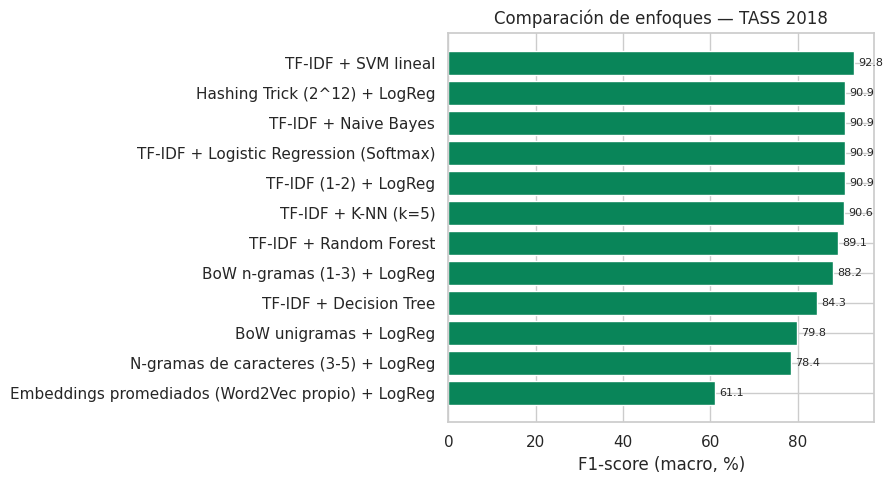

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
order = results_df.sort_values('F1-score')
bars = ax.barh(order['Enfoque'], order['F1-score'], color='#098559')
ax.set_xlabel('F1-score (macro, %)')
ax.set_title('Comparación de enfoques — TASS 2018')
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=8)
plt.tight_layout()
plt.show()

> **Interpretación:** con el corpus sintético de demostración estas cifras son solo ilustrativas de la mecánica del pipeline, no una comparación válida sobre datos reales de TASS — los patrones son artificialmente fáciles de separar por diseño. Al sustituir por el corpus real de TASS 2018, esta misma tabla sí sirve como comparación experimental legítima. Como referencia, los sistemas ganadores de TASS 2018 alcanzaron ≈0.65 de F1 macro con ensambles y embeddings específicos del dominio.

---

## 13. Extensiones sugeridas

1. **Embeddings preentrenados**: sustituir el Word2Vec entrenado en el propio corpus por FastText (`cc.es.300.bin`) o por embeddings contextuales (BERT multilingüe) — ver el notebook de *Text Representation*.
2. **SMOTE en vez de RandomOverSampler**: genera ejemplos minoritarios sintéticos por interpolación en el espacio de features, en lugar de duplicar ejemplos existentes.
3. **Búsqueda de hiperparámetros**: usar `GridSearchCV` o `RandomizedSearchCV` para afinar `C` (Logistic Regression/SVM), `max_depth` (árboles) o `n_neighbors` (KNN).
4. **Análisis de errores**: inspeccionar los tweets mal clasificados por clase — NEU y NONE suelen ser las más difíciles de distinguir entre sí.
5. **Fine-tuning de un modelo preentrenado**: ajustar BERT multilingüe (`bert-base-multilingual-cased`) sobre TASS suele superar claramente a todos los enfoques clásicos de este notebook, al costo de mayor tiempo de entrenamiento y necesidad de GPU.
6. **Adaptación de dominio**: reentrenar sobre un dominio específico (reseñas de hoteles, tweets políticos) para mejorar el desempeño en esa aplicación concreta.